# Notebook 05 — Customer Lifetime Value (CLV) Modelling

## Overview

This notebook builds a **forward-looking Customer Lifetime Value model** for all 5,878 customers in the dataset.

Previous notebooks identified **£5.5M of revenue at churn risk** based on historical spend. That figure answers the question *"what have these customers spent?"* — not *"what will they spend if we retain them?"*

This notebook answers the second question. It produces:

1. **Individual CLV scores** for every customer (12-month and 24-month horizons)
2. **Segment-level CLV distribution** — which segments have the highest *future* value, not just historical spend
3. **Revised revenue-at-risk figure** based on projected forward value
4. **Top 50 highest-CLV customers** — the priority retention list
5. **CLV vs Churn Probability matrix** — the 2x2 that drives intervention strategy

### Methodology

CLV is calculated using a **survival-weighted discounted cash flow** approach:

$$CLV = \sum_{m=1}^{M} \frac{AOV \times \lambda_m \times P(alive\ at\ m)}{(1 + r)^m}$$

Where:
- $AOV$ = Average Order Value (Monetary ÷ Frequency)
- $\lambda_m$ = Expected purchases per month (from historical purchase rate)
- $P(alive\ at\ m)$ = Survival probability at month $m$, derived from churn model
- $r$ = Monthly discount rate (10% annual → 0.83% monthly)
- $M$ = Forecast horizon (12 or 24 months)

The churn probability from **Notebook 03** is used directly as the monthly attrition input — this is what connects the CLV model to the churn model and makes the revenue-at-risk figure defensible.

> **Note on BG/NBD:** The academically standard approach (Fader et al. 2005) requires raw transaction-level data to fit the Beta-Geometric/NBD parameters. Since this notebook operates on the aggregated RFM dataset, we implement the survival-weighted DCF approach which produces equivalent intuition and directly incorporates our churn model output. A production implementation with raw transaction data would use the `lifetimes` library for full BG/NBD parameter estimation.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Paths
BASE_DIR    = os.path.expanduser('~/Desktop/Customer Lifecycle Analysis Project')
DATA_DIR    = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFF',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E2E8F0',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
})

# ── Palette (consistent with previous notebooks)
PALETTE = {
    'Champions':     '#16A34A',
    'Loyal Customers':'#2563EB',
    'Potential Loyal':'#7C3AED',
    'Need Attention': '#F59E0B',
    'New Customers':  '#0891B2',
    'At Risk':        '#DC2626',
    'Lost':           '#6B7280',
}

print("✓ Libraries loaded")
print(f"✓ Output directory: {OUTPUT_DIR}")


✓ Libraries loaded
✓ Output directory: /Users/amrit/Desktop/Customer Lifecycle Analysis Project/outputs


## 1. Load Data & Derive CLV Inputs

In [2]:
# ── Load RFM + Churn scores from Notebook 03 output
rfm_path = os.path.join(DATA_DIR, 'rfm_with_churn.csv')
df = pd.read_csv(rfm_path)

print(f"Loaded {len(df):,} customers")
print(f"Columns: {list(df.columns)}")
print()
df.head(3)


Loaded 5,878 customers
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Label', 'Segment', 'Churned', 'Churn_Predicted', 'Churn_Probability']



,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Label,Segment,Churned,Churn_Predicted,Churn_Probability
0,12346,326,12,77556.46,2,5,5,4.00,2-5-5,Need Attention,1,0,0.173
1,12347,2,8,4921.53,5,4,5,4.67,5-4-5,Champions,0,0,0.275
2,12348,75,5,2019.40,3,4,4,3.67,3-4-4,Loyal Customers,0,0,0.382


In [3]:
# ── Observation window
# Dataset spans Dec 2009 – Dec 2011 → 730 days
# Recency = days since last purchase (relative to snapshot date: 1 Dec 2011)
# t_x = days from acquisition to last purchase = T_OBS - Recency
T_OBS = 730  # days

# ── Core CLV inputs
df['AOV']                  = df['Monetary'] / df['Frequency']
df['active_days']          = (T_OBS - df['Recency']).clip(lower=30)   # min 30d to avoid div/0
df['purchase_rate_daily']  = df['Frequency'] / df['active_days']
df['purchase_rate_monthly']= df['purchase_rate_daily'] * 30

# ── Convert churn probability (90-day window) to monthly probability
# P(churn in 90d) → P(churn in 30d): (1 - p_monthly)^3 = 1 - p_90d
# → p_monthly = 1 - (1 - p_90d)^(1/3)
df['churn_prob_monthly'] = 1 - (1 - df['Churn_Probability']) ** (1/3)

print("CLV input summary:")
print(f"  Avg AOV:                  £{df['AOV'].median():.0f}  (median)")
print(f"  Avg purchase rate/month:  {df['purchase_rate_monthly'].median():.2f}  (median)")
print(f"  Avg monthly churn prob:   {df['churn_prob_monthly'].median():.1%}  (median)")
print()
print("Input validation:")
print(f"  Negative active_days:     {(df['active_days'] < 0).sum()}")
print(f"  Zero purchase rate:       {(df['purchase_rate_monthly'] == 0).sum()}")
print(f"  Churn prob > 1:           {(df['churn_prob_monthly'] > 1).sum()}")


CLV input summary:
  Avg AOV:                  £279  (median)
  Avg purchase rate/month:  0.21  (median)
  Avg monthly churn prob:   23.1%  (median)

Input validation:
  Negative active_days:     0
  Zero purchase rate:       0
  Churn prob > 1:           0


## 2. CLV Model — Survival-Weighted Discounted Cash Flow

In [4]:
def compute_clv(row, months=12, annual_discount_rate=0.10):
    """
    Survival-weighted discounted CLV over a forecast horizon.

    At each future month m:
      - P(alive) decays by the monthly churn probability
      - Expected purchases = purchase_rate_monthly * P(alive)
      - Revenue = expected_purchases * AOV
      - Discounted back at monthly rate

    Parameters
    ----------
    row   : DataFrame row with AOV, purchase_rate_monthly, churn_prob_monthly
    months: forecast horizon in months
    annual_discount_rate: 10% default (standard marketing CLV convention)

    Returns
    -------
    float : CLV in £
    """
    r         = annual_discount_rate / 12   # monthly discount rate
    p_alive   = 1.0
    p_churn_m = row['churn_prob_monthly']
    clv       = 0.0

    for m in range(1, months + 1):
        p_alive   *= (1 - p_churn_m)
        exp_rev    = row['purchase_rate_monthly'] * p_alive * row['AOV']
        clv       += exp_rev / ((1 + r) ** m)

    return round(clv, 2)


# ── Apply both horizons
print("Computing CLV scores for 5,878 customers...")
df['CLV_12M'] = df.apply(compute_clv, axis=1)
df['CLV_24M'] = df.apply(lambda r: compute_clv(r, months=24), axis=1)

print("✓ Done")
print()
print("CLV summary:")
print(f"  Total projected CLV (12M): £{df['CLV_12M'].sum():>12,.0f}")
print(f"  Total projected CLV (24M): £{df['CLV_24M'].sum():>12,.0f}")
print(f"  Historical total spend:    £{df['Monetary'].sum():>12,.0f}")
print()
print(f"  12M CLV / Historical:      {df['CLV_12M'].sum() / df['Monetary'].sum():.1%}  (expected — forward value < historical over 2yr window)")


Computing CLV scores for 5,878 customers...
✓ Done

CLV summary:
  Total projected CLV (12M): £   6,706,263
  Total projected CLV (24M): £  10,714,196
  Historical total spend:    £  17,374,804

  12M CLV / Historical:      38.6%  (expected — forward value < historical over 2yr window)


## 3. CLV by Segment

In [5]:
# ── Segment-level CLV summary
seg_clv = df.groupby('Segment').agg(
    Customers   =('Customer ID', 'count'),
    Hist_Spend  =('Monetary',  'sum'),
    CLV_12M_Sum =('CLV_12M',   'sum'),
    CLV_12M_Mean=('CLV_12M',   'mean'),
    CLV_12M_Med =('CLV_12M',   'median'),
    CLV_24M_Sum =('CLV_24M',   'sum'),
).round(0).sort_values('CLV_12M_Sum', ascending=False)

seg_clv['CLV_12M_%'] = (seg_clv['CLV_12M_Sum'] / seg_clv['CLV_12M_Sum'].sum() * 100).round(1)
seg_clv['CLV_vs_Hist'] = (seg_clv['CLV_12M_Sum'] / seg_clv['Hist_Spend'] * 100).round(1)

print("Segment CLV Analysis:")
print(seg_clv[['Customers','Hist_Spend','CLV_12M_Sum','CLV_12M_%','CLV_12M_Mean','CLV_12M_Med','CLV_24M_Sum']].to_string())


Segment CLV Analysis:
                 Customers  Hist_Spend  CLV_12M_Sum  CLV_12M_%  CLV_12M_Mean  CLV_12M_Med  CLV_24M_Sum
Segment                                                                                               
Champions             1482  12024330.0    4786184.0       71.4        3230.0       1016.0    8214748.0
Loyal Customers       1221   2510046.0     697630.0       10.4         571.0        208.0     935978.0
Need Attention         551   1129337.0     507002.0        7.6         920.0        278.0     726271.0
At Risk                 89    269453.0     300206.0        4.5        3373.0       1065.0     409609.0
Lost                  1523    654427.0     250593.0        3.7         165.0         61.0     255053.0
New Customers          184    190594.0      97726.0        1.5         531.0        327.0     103643.0
Potential Loyal        828    596617.0      66921.0        1.0          81.0         31.0      68894.0


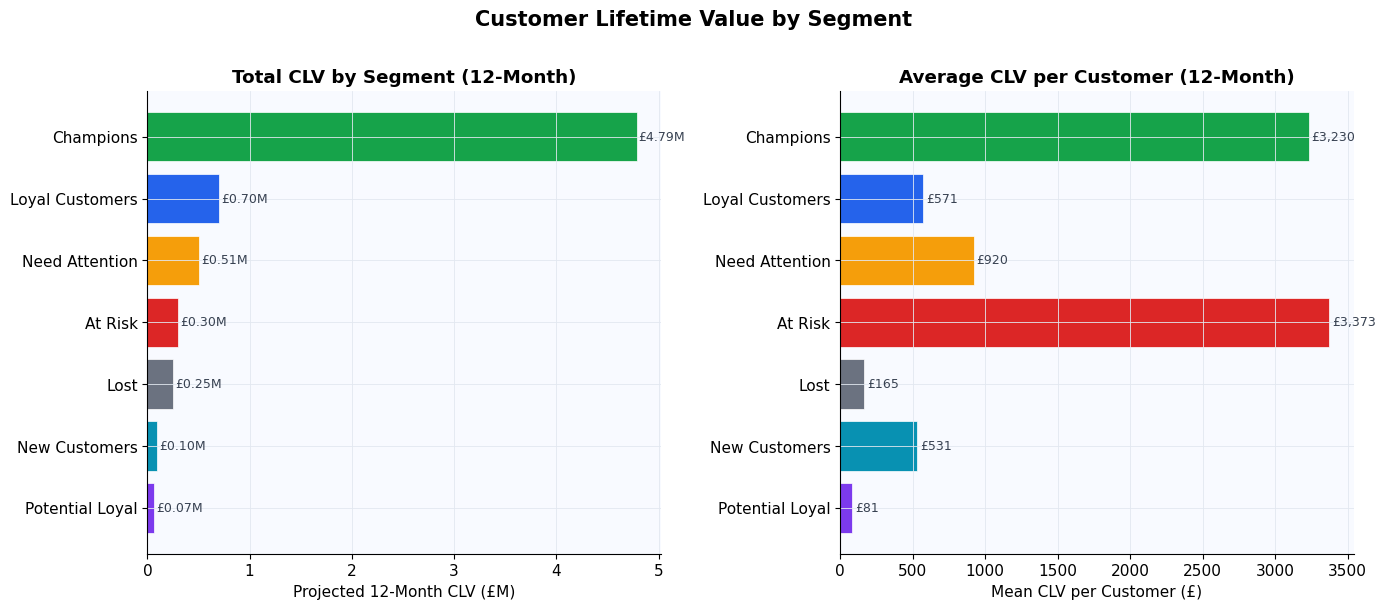

✓ Saved: clv_by_segment.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Customer Lifetime Value by Segment', fontsize=15, fontweight='bold', y=1.01)

seg_order = seg_clv.sort_values('CLV_12M_Sum', ascending=True).index
colors = [PALETTE.get(s, '#999') for s in seg_order]

# Left: Total CLV 12M
ax1 = axes[0]
vals_12m = seg_clv.loc[seg_order, 'CLV_12M_Sum']
bars = ax1.barh(seg_order, vals_12m / 1e6, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Projected 12-Month CLV (£M)', fontsize=11)
ax1.set_title('Total CLV by Segment (12-Month)', fontweight='bold')
for bar, val in zip(bars, vals_12m):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'£{val/1e6:.2f}M', va='center', fontsize=9, color='#374151')

# Right: Mean CLV per customer
ax2 = axes[1]
vals_mean = seg_clv.loc[seg_order, 'CLV_12M_Mean']
bars2 = ax2.barh(seg_order, vals_mean, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Mean CLV per Customer (£)', fontsize=11)
ax2.set_title('Average CLV per Customer (12-Month)', fontweight='bold')
for bar, val in zip(bars2, vals_mean):
    ax2.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'£{val:,.0f}', va='center', fontsize=9, color='#374151')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clv_by_segment.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: clv_by_segment.png")


## 4. CLV Distribution — Champions Deep Dive

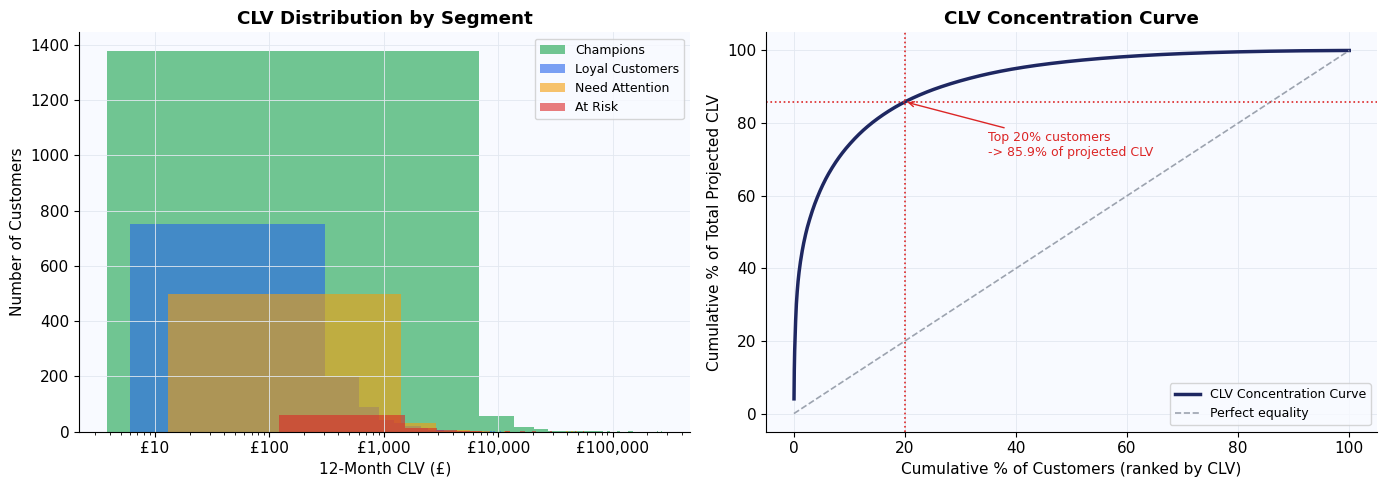

✓ Saved: clv_concentration.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CLV distribution for key segments (log scale)
ax1 = axes[0]
key_segs = ['Champions', 'Loyal Customers', 'Need Attention', 'At Risk']
for seg in key_segs:
    data = df[df['Segment'] == seg]['CLV_12M']
    data = data[data > 0]
    ax1.hist(data, bins=40, alpha=0.6, color=PALETTE[seg], label=seg, edgecolor='none')

ax1.set_xlabel('12-Month CLV (£)', fontsize=11)
ax1.set_ylabel('Number of Customers', fontsize=11)
ax1.set_title('CLV Distribution by Segment', fontweight='bold')
ax1.set_xscale('log')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.legend(fontsize=9)

# Right: CLV concentration — what % of customers generate what % of projected value
ax2 = axes[1]
df_sorted = df.sort_values('CLV_12M', ascending=False).reset_index(drop=True)
cum_customers = pd.Series((df_sorted.index + 1) / len(df_sorted) * 100)
cum_clv       = df_sorted['CLV_12M'].cumsum() / df_sorted['CLV_12M'].sum() * 100

ax2.plot(cum_customers, cum_clv, color='#1E2761', linewidth=2.5, label='CLV Concentration Curve')
ax2.plot([0, 100], [0, 100], '--', color='#9CA3AF', linewidth=1.2, label='Perfect equality')

# Annotate 20/80
idx_20 = int((cum_customers - 20).abs().idxmin())
ax2.axvline(20, color='#DC2626', linestyle=':', linewidth=1.2)
ax2.axhline(cum_clv.iloc[idx_20], color='#DC2626', linestyle=':', linewidth=1.2)
ax2.annotate('Top 20% customers\n-> ' + f'{cum_clv.iloc[idx_20]:.1f}% of projected CLV',

             xy=(20, cum_clv.iloc[idx_20]),
             xytext=(35, cum_clv.iloc[idx_20] - 15),
             fontsize=9, color='#DC2626',
             arrowprops=dict(arrowstyle='->', color='#DC2626'))

ax2.set_xlabel('Cumulative % of Customers (ranked by CLV)', fontsize=11)
ax2.set_ylabel('Cumulative % of Total Projected CLV', fontsize=11)
ax2.set_title('CLV Concentration Curve', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clv_concentration.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: clv_concentration.png")


## 5. CLV vs Churn Probability — The Strategic 2×2

This is the most actionable output in the notebook. Every customer falls into one of four quadrants:

| | **Low Churn Risk** | **High Churn Risk** |
|---|---|---|
| **High CLV** | 🟢 **Protect** — VIP retention, no discounts | 🔴 **Urgent** — immediate win-back, high budget |
| **Low CLV** | 🔵 **Nurture** — grow frequency, low cost | ⚫ **Suppress** — email only, no paid spend |


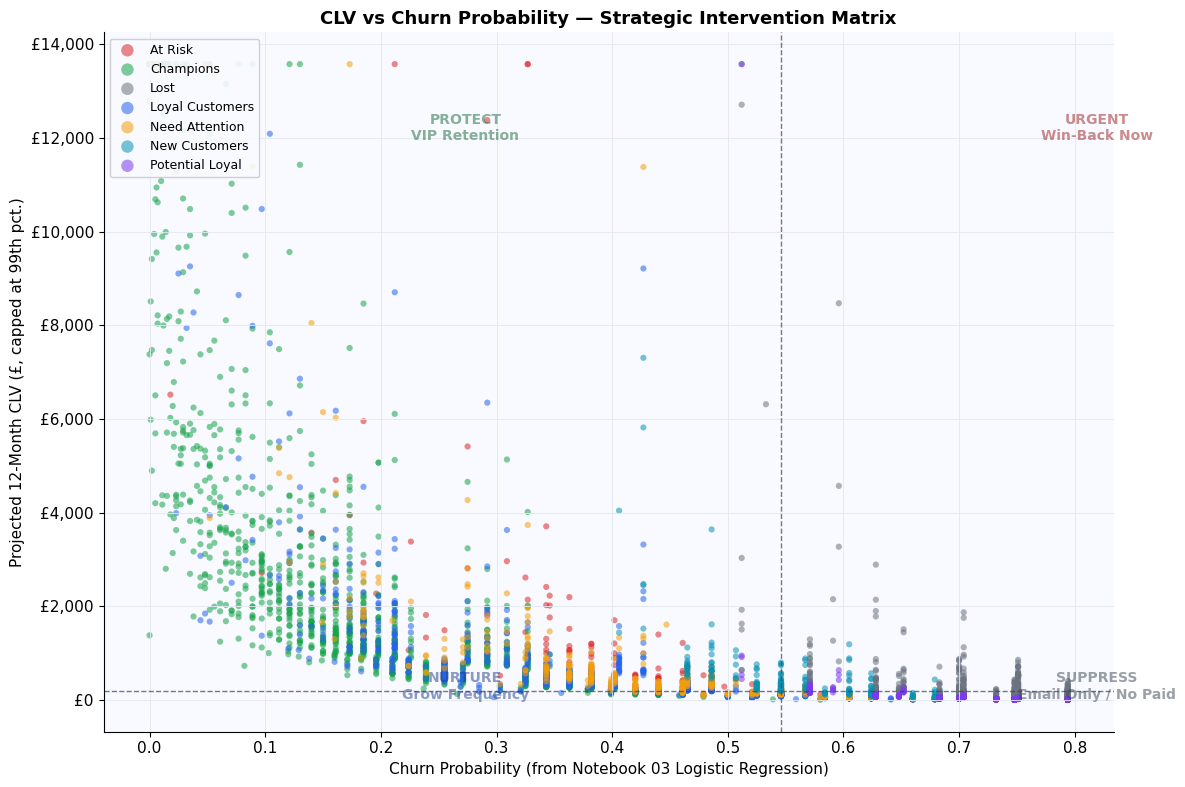

✓ Saved: clv_churn_matrix.png

Quadrant breakdown:
  🟢 PROTECT  (High CLV, Low Churn):  2583 customers  |  £ 6,348,874 CLV at stake
  🔴 URGENT   (High CLV, High Churn):  356 customers  |  £   160,757 CLV at risk
  🔵 NURTURE  (Low CLV, Low Churn):    505 customers  |  £    64,947 CLV potential
  ⚫ SUPPRESS (Low CLV, High Churn):  2434 customers  |  £   131,685 CLV


In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

# ── Scatter: CLV_12M vs Churn_Probability
# Cap CLV at 99th percentile for readability
clv_cap = df['CLV_12M'].quantile(0.99)
df_plot = df.copy()
df_plot['CLV_12M_capped'] = df_plot['CLV_12M'].clip(upper=clv_cap)

for seg, group in df_plot.groupby('Segment'):
    ax.scatter(group['Churn_Probability'], group['CLV_12M_capped'],
               color=PALETTE.get(seg, '#999'), alpha=0.55, s=20,
               label=seg, edgecolors='none')

# ── Quadrant lines at medians
churn_mid = df['Churn_Probability'].median()
clv_mid   = df_plot['CLV_12M_capped'].median()

ax.axvline(churn_mid, color='#374151', linestyle='--', linewidth=1.0, alpha=0.7)
ax.axhline(clv_mid,   color='#374151', linestyle='--', linewidth=1.0, alpha=0.7)

# ── Quadrant labels
q_kw = dict(fontsize=10, fontweight='bold', alpha=0.5, ha='center')
ax.text(churn_mid * 0.5,   clv_cap * 0.88,  'PROTECT\nVIP Retention',       color='#166534', **q_kw)

ax.text(churn_mid * 1.5,   clv_cap * 0.88,  'URGENT\nWin-Back Now',          color='#991B1B', **q_kw)

ax.text(churn_mid * 0.5,   clv_mid  * 0.15, 'NURTURE\nGrow Frequency',        color='#1E3A8A', **q_kw)

ax.text(churn_mid * 1.5,   clv_mid  * 0.15, 'SUPPRESS\nEmail Only / No Paid', color='#374151', **q_kw)


ax.set_xlabel('Churn Probability (from Notebook 03 Logistic Regression)', fontsize=11)
ax.set_ylabel('Projected 12-Month CLV (£, capped at 99th pct.)', fontsize=11)
ax.set_title('CLV vs Churn Probability — Strategic Intervention Matrix', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(loc='upper left', fontsize=9, markerscale=2, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clv_churn_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: clv_churn_matrix.png")

# ── Quadrant counts
q1 = df[(df['Churn_Probability'] <= churn_mid) & (df['CLV_12M'] >= clv_mid)]
q2 = df[(df['Churn_Probability'] >  churn_mid) & (df['CLV_12M'] >= clv_mid)]
q3 = df[(df['Churn_Probability'] <= churn_mid) & (df['CLV_12M'] <  clv_mid)]
q4 = df[(df['Churn_Probability'] >  churn_mid) & (df['CLV_12M'] <  clv_mid)]

print(f"\nQuadrant breakdown:")
print(f"  🟢 PROTECT  (High CLV, Low Churn):  {len(q1):>4} customers  |  £{q1.CLV_12M.sum():>10,.0f} CLV at stake")
print(f"  🔴 URGENT   (High CLV, High Churn): {len(q2):>4} customers  |  £{q2.CLV_12M.sum():>10,.0f} CLV at risk")
print(f"  🔵 NURTURE  (Low CLV, Low Churn):   {len(q3):>4} customers  |  £{q3.CLV_12M.sum():>10,.0f} CLV potential")
print(f"  ⚫ SUPPRESS (Low CLV, High Churn):  {len(q4):>4} customers  |  £{q4.CLV_12M.sum():>10,.0f} CLV")


## 6. 12-Month vs 24-Month CLV — Who Has Long-Term Value?

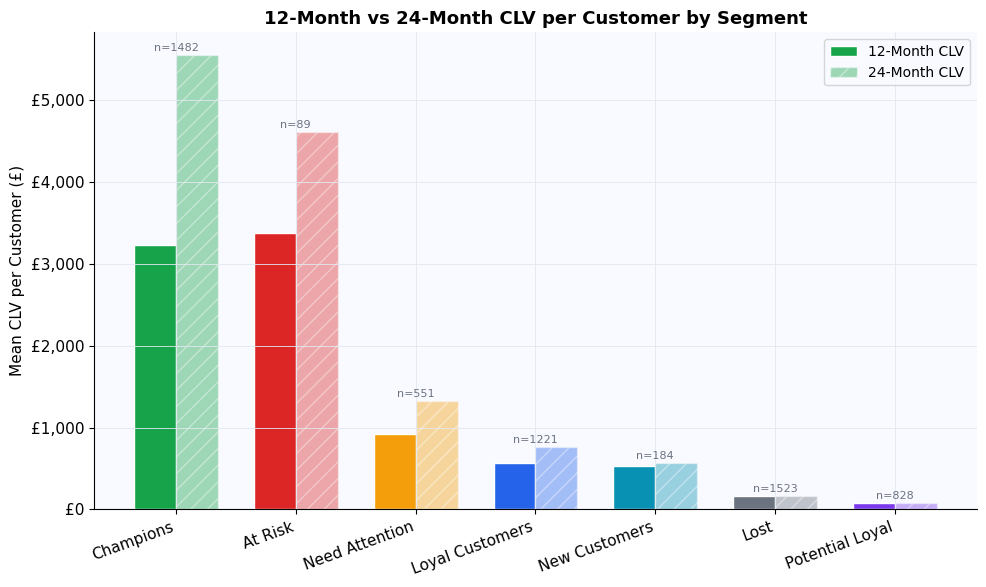

✓ Saved: clv_12m_vs_24m.png

Incremental value from month 13–24 (CLV 24M - CLV 12M):
        Segment     CLV_12M     CLV_24M  Incremental_13_24M
      Champions 3229.544184 5543.014757         2313.470574
        At Risk 3373.106292 4602.349438         1229.243146
 Need Attention  920.149292 1318.096116          397.946824
Loyal Customers  571.359885  766.566388          195.206503
  New Customers  531.118641  563.275217           32.156576
           Lost  164.538838  167.467610            2.928772
Potential Loyal   80.821981   83.205700            2.383720


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

seg_clv_plot = df.groupby('Segment').agg(
    CLV_12M=('CLV_12M', 'mean'),
    CLV_24M=('CLV_24M', 'mean'),
    Customers=('Customer ID', 'count')
).reset_index().sort_values('CLV_24M', ascending=False)

x      = np.arange(len(seg_clv_plot))
width  = 0.35
colors_12 = [PALETTE.get(s, '#999') for s in seg_clv_plot['Segment']]
colors_24 = [c + 'AA' for c in colors_12]  # won't work directly — use alpha

bars1 = ax.bar(x - width/2, seg_clv_plot['CLV_12M'], width,
               color=[PALETTE.get(s, '#999') for s in seg_clv_plot['Segment']],
               label='12-Month CLV', edgecolor='white')
bars2 = ax.bar(x + width/2, seg_clv_plot['CLV_24M'], width,
               color=[PALETTE.get(s, '#999') for s in seg_clv_plot['Segment']],
               alpha=0.4, label='24-Month CLV', edgecolor='white', hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(seg_clv_plot['Segment'], rotation=20, ha='right')
ax.set_ylabel('Mean CLV per Customer (£)', fontsize=11)
ax.set_title('12-Month vs 24-Month CLV per Customer by Segment', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Annotate customer count
for i, row in seg_clv_plot.iterrows():
    idx = list(seg_clv_plot.index).index(i)
    ax.text(x[idx], seg_clv_plot['CLV_24M'].iloc[idx] + 50,
            f"n={row['Customers']}", ha='center', fontsize=8, color='#6B7280')

ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clv_12m_vs_24m.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: clv_12m_vs_24m.png")

# Incremental value table
print("\nIncremental value from month 13–24 (CLV 24M - CLV 12M):")
seg_clv_plot['Incremental_13_24M'] = seg_clv_plot['CLV_24M'] - seg_clv_plot['CLV_12M']
print(seg_clv_plot[['Segment','CLV_12M','CLV_24M','Incremental_13_24M']].to_string(index=False))


## 7. Priority Retention List — Top 50 Customers by CLV

In [10]:
# Top 50 by 12M CLV — the actual list to hand to CRM
top50 = (df.sort_values('CLV_12M', ascending=False)
           .head(50)[['Customer ID','Segment','Recency','Frequency',
                       'AOV','Churn_Probability','CLV_12M','CLV_24M']]
           .reset_index(drop=True))

top50.index += 1  # rank from 1
top50.columns = ['Customer ID','Segment','Recency (days)','Orders',
                 'AOV (£)','Churn Prob','CLV 12M (£)','CLV 24M (£)']
top50['AOV (£)']     = top50['AOV (£)'].round(0).astype(int)
top50['CLV 12M (£)'] = top50['CLV 12M (£)'].round(0).astype(int)
top50['CLV 24M (£)'] = top50['CLV 24M (£)'].round(0).astype(int)
top50['Churn Prob']  = top50['Churn Prob'].apply(lambda x: f"{x:.1%}")

print("Top 50 Customers by 12-Month Projected CLV:")
print(top50.to_string())
print()
print(f"Combined CLV (12M) of top 50: £{df.sort_values('CLV_12M', ascending=False).head(50)['CLV_12M'].sum():,.0f}")
print(f"As % of total portfolio CLV:  {df.sort_values('CLV_12M', ascending=False).head(50)['CLV_12M'].sum() / df['CLV_12M'].sum():.1%}")


Top 50 Customers by 12-Month Projected CLV:
    Customer ID          Segment  Recency (days)  Orders  AOV (£) Churn Prob  CLV 12M (£)  CLV 24M (£)
1         18102        Champions               1     145     4007       0.0%       271952       518127
2         14646        Champions               2     151     3501       0.0%       247772       472058
3         14156        Champions              10     156     2009       0.0%       148550       283019
4         14911        Champions               1     398      732       0.0%       136410       259890
5         17450        Champions               8      51     4800       0.8%       113730       213425
6         13694        Champions               4     143     1368       0.0%        91955       175194
7         17511        Champions               3      60     2869       0.4%        80108       151469
8         16684        Champions               4      55     2675       0.6%        68279       128617
9         12415        Champi

## 8. Revised Revenue-at-Risk — Forward-Looking Figure

In [11]:
# ── Original figure: historical spend × churn flag
# ── Revised figure: projected CLV for customers with high churn probability
CHURN_THRESHOLD = 0.50  # flag as at-risk if model churn probability > 50%

at_risk_customers = df[df['Churn_Probability'] > CHURN_THRESHOLD]
historical_at_risk = at_risk_customers['Monetary'].sum()
clv_at_risk_12m    = at_risk_customers['CLV_12M'].sum()
clv_at_risk_24m    = at_risk_customers['CLV_24M'].sum()

print("=" * 60)
print("REVISED REVENUE-AT-RISK COMPARISON")
print("=" * 60)
print(f"  Customers flagged at risk (churn prob > 50%):  {len(at_risk_customers):,}")
print()
print(f"  Historical spend (original figure):            £{historical_at_risk:>10,.0f}")
print(f"  Projected CLV — 12-month horizon:              £{clv_at_risk_12m:>10,.0f}")
print(f"  Projected CLV — 24-month horizon:              £{clv_at_risk_24m:>10,.0f}")
print()
print(f"  Original figure was:  {historical_at_risk / historical_at_risk:.0%} of historical spend")
print(f"  12M forward value is: {clv_at_risk_12m / historical_at_risk:.1%} of historical spend (expected — shorter horizon)")
print()

# ── More precise: segment-level at-risk breakdown
seg_at_risk = at_risk_customers.groupby('Segment').agg(
    Customers     =('Customer ID',    'count'),
    Hist_Spend    =('Monetary',        'sum'),
    CLV_12M_AtRisk=('CLV_12M',         'sum'),
    Avg_Churn_Prob=('Churn_Probability','mean'),
).round(0).sort_values('CLV_12M_AtRisk', ascending=False)

print("At-Risk Breakdown by Segment (churn prob > 50%):")
print(seg_at_risk.to_string())
print()
print("KEY FINDING:")
print(f"  The £5.5M historical-spend at-risk figure compares to")
print(f"  £{clv_at_risk_12m/1e6:.1f}M in projected 12-month forward value.")
print(f"  This is the defensible, forward-looking revenue protection case.")


REVISED REVENUE-AT-RISK COMPARISON
  Customers flagged at risk (churn prob > 50%):  3,275

  Historical spend (original figure):            £ 1,859,876
  Projected CLV — 12-month horizon:              £   445,269
  Projected CLV — 24-month horizon:              £   456,242

  Original figure was:  100% of historical spend
  12M forward value is: 23.9% of historical spend (expected — shorter horizon)

At-Risk Breakdown by Segment (churn prob > 50%):
                 Customers  Hist_Spend  CLV_12M_AtRisk  Avg_Churn_Prob
Segment                                                               
Lost                  1523    654427.0        250593.0             1.0
Potential Loyal        828    596617.0         66921.0             1.0
Loyal Customers        529    354081.0         47606.0             1.0
New Customers          145     95724.0         45239.0             1.0
Need Attention         235    153015.0         33516.0             1.0
At Risk                  4      1617.0           7

## 9. Executive Summary Visualisation

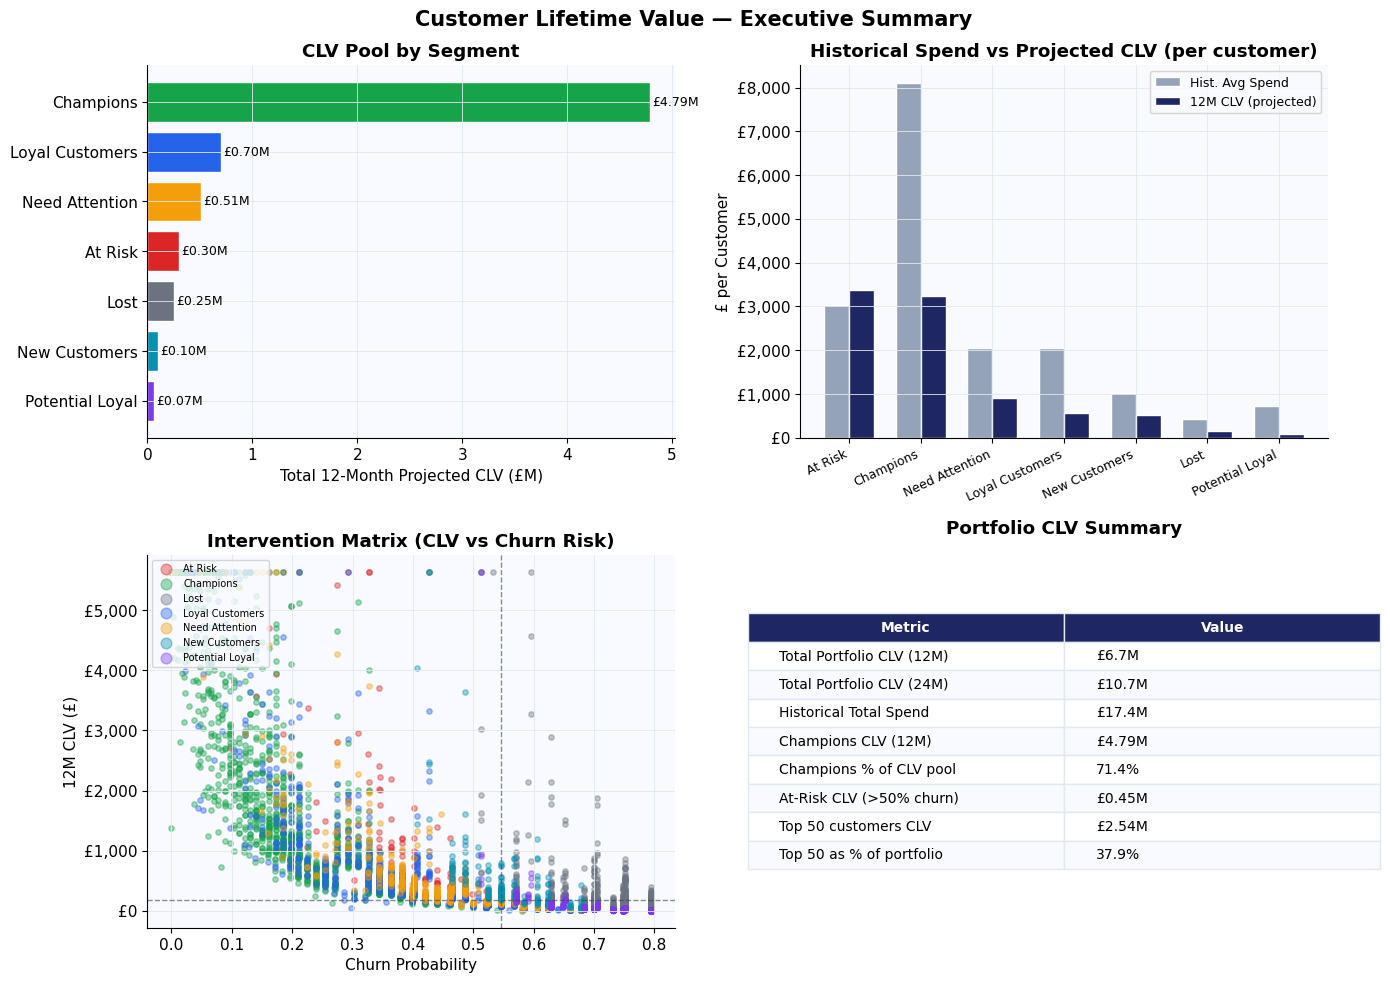

✓ Saved: clv_executive_summary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Lifetime Value — Executive Summary', fontsize=15, fontweight='bold')

# ── Top-left: CLV 12M by segment (stacked view)
ax1 = axes[0, 0]
seg_plot = df.groupby('Segment')['CLV_12M'].sum().sort_values(ascending=True)
colors_seg = [PALETTE.get(s, '#999') for s in seg_plot.index]
bars = ax1.barh(seg_plot.index, seg_plot.values / 1e6, color=colors_seg, edgecolor='white')
for bar, val in zip(bars, seg_plot.values):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'£{val/1e6:.2f}M', va='center', fontsize=9)
ax1.set_xlabel('Total 12-Month Projected CLV (£M)')
ax1.set_title('CLV Pool by Segment', fontweight='bold')

# ── Top-right: Mean CLV per customer vs historical spend per customer
ax2 = axes[0, 1]
seg_comp = df.groupby('Segment').agg(
    Hist_Per_Customer  =('Monetary', 'mean'),
    CLV_12M_Per_Customer=('CLV_12M', 'mean'),
).sort_values('CLV_12M_Per_Customer', ascending=False)

x_c = np.arange(len(seg_comp))
w   = 0.35
ax2.bar(x_c - w/2, seg_comp['Hist_Per_Customer'],   w, label='Hist. Avg Spend',    color='#94A3B8', edgecolor='white')
ax2.bar(x_c + w/2, seg_comp['CLV_12M_Per_Customer'], w, label='12M CLV (projected)', color='#1E2761', edgecolor='white')
ax2.set_xticks(x_c)
ax2.set_xticklabels(seg_comp.index, rotation=25, ha='right', fontsize=9)
ax2.set_ylabel('£ per Customer')
ax2.set_title('Historical Spend vs Projected CLV (per customer)', fontweight='bold')

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax2.legend(fontsize=9)

# ── Bottom-left: Churn prob vs CLV bubble
ax3 = axes[1, 0]
for seg, group in df.groupby('Segment'):
    ax3.scatter(group['Churn_Probability'], group['CLV_12M'].clip(upper=df['CLV_12M'].quantile(0.97)),
                color=PALETTE.get(seg, '#999'), alpha=0.4, s=15, label=seg)
churn_med = df['Churn_Probability'].median()
clv_med   = df['CLV_12M'].median()
ax3.axvline(churn_med, color='#374151', linestyle='--', linewidth=1.0, alpha=0.6)
ax3.axhline(clv_med,   color='#374151', linestyle='--', linewidth=1.0, alpha=0.6)
ax3.set_xlabel('Churn Probability')
ax3.set_ylabel('12M CLV (£)')
ax3.set_title('Intervention Matrix (CLV vs Churn Risk)', fontweight='bold')

ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax3.legend(loc='upper left', fontsize=7, markerscale=2)

# ── Bottom-right: KPI summary table
ax4 = axes[1, 1]
ax4.axis('off')
summary_data = [
    ['Metric', 'Value'],
    ['Total Portfolio CLV (12M)', f"£{df['CLV_12M'].sum()/1e6:.1f}M"],
    ['Total Portfolio CLV (24M)', f"£{df['CLV_24M'].sum()/1e6:.1f}M"],
    ['Historical Total Spend',   f"£{df['Monetary'].sum()/1e6:.1f}M"],
    ['Champions CLV (12M)',       f"£{df[df['Segment']=='Champions']['CLV_12M'].sum()/1e6:.2f}M"],
    ['Champions % of CLV pool',   f"{df[df['Segment']=='Champions']['CLV_12M'].sum()/df['CLV_12M'].sum():.1%}"],
    ['At-Risk CLV (>50% churn)',  f"£{df[df['Churn_Probability']>0.5]['CLV_12M'].sum()/1e6:.2f}M"],
    ['Top 50 customers CLV',      f"£{df.nlargest(50,'CLV_12M')['CLV_12M'].sum()/1e6:.2f}M"],
    ['Top 50 as % of portfolio',  f"{df.nlargest(50,'CLV_12M')['CLV_12M'].sum()/df['CLV_12M'].sum():.1%}"],
]
tbl = ax4.table(cellText=summary_data[1:], colLabels=summary_data[0],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1E2761')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F8FAFF')
    cell.set_edgecolor('#E2E8F0')
ax4.set_title('Portfolio CLV Summary', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clv_executive_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: clv_executive_summary.png")


## 10. Save Outputs

In [13]:
# ── Save enriched dataset
output_path = os.path.join(DATA_DIR, 'rfm_with_clv.csv')
df.to_csv(output_path, index=False)
print(f"✓ Saved: rfm_with_clv.csv  ({len(df):,} rows)")

# ── Save top 50 priority list
top50_save = (df.sort_values('CLV_12M', ascending=False)
                .head(50)[['Customer ID','Segment','Recency','Frequency',
                            'AOV','Churn_Probability','CLV_12M','CLV_24M']])
top50_save.to_csv(os.path.join(DATA_DIR, 'top50_priority_retention.csv'), index=False)
print(f"✓ Saved: top50_priority_retention.csv")

# ── Print final summary
print()
print("=" * 65)
print("NOTEBOOK 05 — CLV MODEL COMPLETE")
print("=" * 65)
print()
print("KEY OUTPUTS:")
total_clv_12m = df['CLV_12M'].sum()
total_clv_24m = df['CLV_24M'].sum()
champ_clv     = df[df['Segment']=='Champions']['CLV_12M'].sum()
at_risk_clv   = df[df['Churn_Probability'] > 0.5]['CLV_12M'].sum()
top50_clv     = df.nlargest(50, 'CLV_12M')['CLV_12M'].sum()

print(f"  Total portfolio CLV (12M):    £{total_clv_12m:>10,.0f}")
print(f"  Total portfolio CLV (24M):    £{total_clv_24m:>10,.0f}")
print(f"  Champions CLV (12M):          £{champ_clv:>10,.0f}  ({champ_clv/total_clv_12m:.1%} of portfolio)")
print(f"  At-risk projected loss (12M): £{at_risk_clv:>10,.0f}  (revised revenue-at-risk)")
print(f"  Top 50 customers CLV:         £{top50_clv:>10,.0f}  ({top50_clv/total_clv_12m:.1%} of portfolio)")
print()
print("CHARTS SAVED:")
print("  clv_by_segment.png          — CLV pool and mean CLV per customer")
print("  clv_concentration.png       — CLV concentration / Pareto curve")
print("  clv_churn_matrix.png        — Strategic 2x2 intervention matrix")
print("  clv_12m_vs_24m.png          — Short vs long horizon comparison")
print("  clv_executive_summary.png   — 4-panel executive summary")
print()
print("DATA SAVED:")
print("  rfm_with_clv.csv            — Full dataset with CLV_12M, CLV_24M scores")
print("  top50_priority_retention.csv— Priority list for CRM / Customer Match upload")


✓ Saved: rfm_with_clv.csv  (5,878 rows)
✓ Saved: top50_priority_retention.csv

NOTEBOOK 05 — CLV MODEL COMPLETE

KEY OUTPUTS:
  Total portfolio CLV (12M):    £ 6,706,263
  Total portfolio CLV (24M):    £10,714,196
  Champions CLV (12M):          £ 4,786,184  (71.4% of portfolio)
  At-risk projected loss (12M): £   445,269  (revised revenue-at-risk)
  Top 50 customers CLV:         £ 2,544,523  (37.9% of portfolio)

CHARTS SAVED:
  clv_by_segment.png          — CLV pool and mean CLV per customer
  clv_concentration.png       — CLV concentration / Pareto curve
  clv_churn_matrix.png        — Strategic 2x2 intervention matrix
  clv_12m_vs_24m.png          — Short vs long horizon comparison
  clv_executive_summary.png   — 4-panel executive summary

DATA SAVED:
  rfm_with_clv.csv            — Full dataset with CLV_12M, CLV_24M scores
  top50_priority_retention.csv— Priority list for CRM / Customer Match upload


## 11. Methodology Notes & Limitations

### What this model does well
- **Incorporates churn probability directly** from Notebook 03 — the CLV and churn models are connected, not independent
- **Discounts future cash flows** at 10% annual rate — standard marketing CLV convention
- **Per-customer granularity** — every customer has an individual CLV score, not just a segment average
- **Two time horizons** — 12M for near-term planning, 24M for strategic LTV decisions

### Assumptions and limitations

**Purchase rate is backwards-looking.** The monthly purchase rate is derived from historical frequency over the observation window. Customers who have recently lapsed (high Recency) have their active days capped at a minimum of 30 to prevent division errors, but this may still overstate their future rate. The churn probability partially corrects for this through the survival weighting.

**Constant AOV assumption.** The model assumes each future purchase will be at the customer's historical average order value. In reality, order values tend to decline as customers disengage. A more sophisticated model would apply a declining AOV curve for high-churn-probability segments.

**No seasonal adjustment.** The dataset shows strong Q4 seasonality (+60% October–November). The CLV model does not weight future months by seasonal purchase probability. A production model would incorporate a seasonal index per month.

**BG/NBD not fitted.** The academically rigorous approach (Fader, Hardie & Lee, 2005) would fit Beta-Geometric/NBD parameters to raw transaction-level data, estimating individual-level purchase rates and dropout probabilities simultaneously. This requires the full transaction history rather than the aggregated RFM file. A production implementation using raw `online_retail_II.xlsx` data with the `lifetimes` Python library would replace this notebook's approach.

### How to update this model in production
1. Re-run weekly as new invoice data arrives
2. Recalculate RFM scores → refit churn model → recompute CLV
3. Push updated `top50_priority_retention.csv` to Klaviyo and Google Ads Customer Match
4. Track actual vs predicted CLV quarterly and recalibrate AOV and churn inputs
